**Instalación de Dependencias**

In [1]:
!pip install pymongo google-cloud-bigquery db-dtypes pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 23.8 MB/s eta 0:00:00


**Configuración**

In [3]:
from google.oauth2 import service_account
from google.cloud import bigquery

KEY_PATH = 'maia-466013-bfc69578e038.json'

GCP_PROJECT = "maia-466013"
BIGQUERY_DATASET_BUSINESS = "ds_business"
BIGQUERY_TABLE_INVENTORIES_SANITIZED_PROD = "inventories-simplify-prod"

credentials = service_account.Credentials.from_service_account_file(KEY_PATH)
client = bigquery.Client(project=GCP_PROJECT, credentials=credentials)

In [47]:
import pandas as pd
import numpy as np
import re

TABLE = f"{GCP_PROJECT}.{BIGQUERY_DATASET_BUSINESS}.`{BIGQUERY_TABLE_INVENTORIES_SANITIZED_PROD}`"

# Campos de atributo (ya sanitizados, sin prefijo vp_)
ATTRIBUTE_FIELDS = [
    "cluster", "compilation", "color", "presentation", "type", "model",
    "size", "measure", "thickness", "weight",
    "volume", "angle", "fabrication", "material",
    "reference"
]

THRESHOLD = 0.90
MIN_PRODUCTS = 10

**Cargar Inventarios Sanitizados**

In [48]:
query = f"""
SELECT *
FROM {TABLE}
"""

df = client.query(query).to_dataframe(create_bqstorage_client=False)
df["synced_at"] = df["synced_at"].astype(str)
print(f"Total inventarios sanitizados: {len(df)}")
print(f"Columnas: {list(df.columns)}")
df.head()

Total inventarios sanitizados: 251
Columnas: ['id', 'sku_equip', 'product', 'description', 'brand', 'unity', 'stock', 'category', 'subcategory', 'cluster', 'compilation', 'color', 'presentation', 'type', 'model', 'size', 'measure', 'thickness', 'weight', 'volume', 'angle', 'fabrication', 'material', 'reference', 'price', 'price_b2b_def', 'price_b2b_inf', 'price_b2c_def', 'price_b2c_inf', 'currency', 'image0', 'image1', 'image2', 'image3', 'techsheet_url', 'keywords', 'account_id', 'synced_at']


,id,sku_equip,product,description,brand,unity,stock,category,subcategory,cluster,...,price_b2c_inf,currency,image0,image1,image2,image3,techsheet_url,keywords,account_id,synced_at
0,6984aa56acb70006f97a21bf,EQ24185,Alambre negro recocido #16 x 100kg,"Es un alambre de acero de bajo carbono, obteni...",Aceros Arequipa,KG,0,Acero,Alambres,Alambres,...,0.00,USD,https://equipindustry-bucket-inventories-prod....,https://equipindustry-bucket-inventories-prod....,None,None,https://equipindustry-bucket-inventories-prod....,[],64c4a90e729c70c61a439246,2026-03-19 13:09:00.330582+00:00
1,6984aa56acb70006f97a21c0,EQ24186,Alambre negro recocido #8 x 100kg,"Es un alambre de acero de bajo carbono, obteni...",Aceros Arequipa,KG,0,Acero,Alambres,Alambres,...,0.00,USD,https://equipindustry-bucket-inventories-prod....,https://equipindustry-bucket-inventories-prod....,None,None,https://equipindustry-bucket-inventories-prod....,[],64c4a90e729c70c61a439246,2026-03-19 13:09:00.330792+00:00
2,6984aa56acb70006f97a21c1,EQ04999,"Barra de construcción Grado 60 1"" 3/8 x 9m","Barras de acero soldables, rectas de sección c...",Aceros Arequipa,UND,0,Acero,Barras de Acero,Barras de Acero,...,84.77,USD,https://equipindustry-bucket-inventories-prod....,None,None,None,https://equipindustry-bucket-inventories-prod....,"[fierro, fierro de construccion, varilla, vari...",64c4a90e729c70c61a439246,2026-03-19 13:09:00.330961+00:00
3,6984aa56acb70006f97a21c2,EQ05001,"Barra de construcción Grado 60 1"" X 9m","Barras de acero soldables, rectas de sección c...",Aceros Arequipa,UND,0,Acero,Barras de Acero,Barras de Acero,...,43.85,USD,https://equipindustry-bucket-inventories-prod....,None,None,None,https://equipindustry-bucket-inventories-prod....,"[fierro, fierro de construccion, varilla, vari...",64c4a90e729c70c61a439246,2026-03-19 13:09:00.331266+00:00
4,6984aa56acb70006f97a21c3,EQ04998,"Barra de construcción Grado 60 1/2"" X 9m","Barras de acero soldables, rectas de sección c...",Aceros Arequipa,UND,0,Acero,Barras de Acero,Barras de Acero,...,10.96,USD,https://equipindustry-bucket-inventories-prod....,None,None,None,https://equipindustry-bucket-inventories-prod....,"[fierro, fierro de construccion, varilla, vari...",64c4a90e729c70c61a439246,2026-03-19 13:09:00.331528+00:00


**Normalización**

In [49]:
def normalize_value(val):
    if pd.isna(val) or val is None:
        return np.nan
    val = str(val).strip()
    val = re.sub(r'\s+', ' ', val)
    if val == '':
        return np.nan
    return val

for field in ATTRIBUTE_FIELDS:
    if field in df.columns:
        df[field] = df[field].apply(normalize_value)

print("Campos con datos:")
filled = df[ATTRIBUTE_FIELDS].notna().sum().sort_values(ascending=False)
print(filled.to_string())
print(f"\nTotal inventarios: {len(df)}")

Campos con datos:
cluster         251
compilation     251
weight          237
presentation    232
color           213
measure          29
type              9
size              0
model             0
thickness         0
volume            0
angle             0
fabrication       0
material          0
reference         0

Total inventarios: 251


**Explorar Categorías y Subcategorías**

In [50]:
# category y subcategory ya son STRING (no arrays), no necesitan explode
df = df[df["subcategory"].notna() & (df["subcategory"] != "")]
df = df[df["category"].notna() & (df["category"] != "")]

sub_counts = df["subcategory"].value_counts()
cat_counts = df["category"].value_counts()

valid_subcats = sub_counts[sub_counts >= MIN_PRODUCTS].index.tolist()
valid_cats = cat_counts[cat_counts >= MIN_PRODUCTS].index.tolist()

print(f"Subcategorias: {len(sub_counts)} total, {len(valid_subcats)} con >= {MIN_PRODUCTS} productos")
print(f"Categorias: {len(cat_counts)} total, {len(valid_cats)} con >= {MIN_PRODUCTS} productos")
print(f"\nTop subcategorias:")
print(sub_counts.head(20).to_string())

Subcategorias: 4 total, 3 con >= 10 productos
Categorias: 2 total, 2 con >= 10 productos

Top subcategorias:
subcategory
Cables             218
Barras de Acero     19
Clavos              10
Alambres             4


**Función de Completitud**

In [51]:
def compute_completeness(df_group, group_col, group_values, fields):
    """Calcula % de completitud de cada campo por grupo."""
    results = {}
    for group_val in group_values:
        mask = df_group[group_col] == group_val
        group_df = df_group.loc[mask, fields]
        total = len(group_df)
        if total < MIN_PRODUCTS:
            continue
        completeness = (group_df.notna().sum() / total * 100).round(2)
        results[group_val] = completeness
    return pd.DataFrame(results).T

**Completitud por Subcategoría y Categoría**

In [52]:
sub_completeness = compute_completeness(df, "subcategory", valid_subcats, ATTRIBUTE_FIELDS)
cat_completeness = compute_completeness(df, "category", valid_cats, ATTRIBUTE_FIELDS)

**Resumen de Completitud**

In [53]:
print("=== RESUMEN ===\n")

print(f"Umbral: {THRESHOLD * 100}%\n")
total_passing = 0
for subcat in sub_completeness.index:
    row = sub_completeness.loc[subcat]
    passing = row[row >= THRESHOLD * 100].index.tolist()
    if passing:
        total = int((df["subcategory"] == subcat).sum())
        print(f"{subcat} ({total} productos): {passing}")
        total_passing += len(passing)

print(f"\nTotal campos >= {THRESHOLD*100}% (suma todas las subcategorias): {total_passing}")
print(f"Subcategorias con al menos 1 campo >= {THRESHOLD*100}%: {sum(1 for subcat in sub_completeness.index if (sub_completeness.loc[subcat] >= THRESHOLD * 100).any())}")

print(f"\nPromedio de completitud por campo:")
print(sub_completeness.mean().sort_values(ascending=False).round(2).to_string())

=== RESUMEN ===

Umbral: 90.0%

Cables (218 productos): ['cluster', 'compilation', 'color', 'presentation', 'weight']
Barras de Acero (19 productos): ['cluster', 'compilation', 'measure']
Clavos (10 productos): ['cluster', 'compilation', 'presentation', 'measure']

Total campos >= 90.0% (suma todas las subcategorias): 12
Subcategorias con al menos 1 campo >= 90.0%: 3

Promedio de completitud por campo:
cluster         100.00
compilation     100.00
presentation     66.67
measure          66.67
weight           63.16
color            31.96
type              1.38
size              0.00
model             0.00
thickness         0.00
volume            0.00
angle             0.00
fabrication       0.00
material          0.00
reference         0.00


**Distribución de Atributos por Inventario**

In [54]:
print("=== DISTRIBUCION DE ATRIBUTOS POR INVENTARIO ===\n")

# Cuantos atributos tiene cada inventario
attr_count = df[ATTRIBUTE_FIELDS].notna().sum(axis=1)
print(f"Atributos por inventario:")
print(attr_count.value_counts().sort_index().to_string())
print(f"\nPromedio de atributos por inventario: {attr_count.mean():.2f}")
print(f"Mediana: {attr_count.median():.0f}")

# Productos por campo
print(f"\nProductos con datos por campo:")
field_counts = df[ATTRIBUTE_FIELDS].notna().sum().sort_values(ascending=False)
for field, count in field_counts.items():
    print(f"  {field}: {count} ({count/len(df)*100:.1f}%)")

=== DISTRIBUCION DE ATRIBUTOS POR INVENTARIO ===

Atributos por inventario:
3      2
4     29
5    220

Promedio de atributos por inventario: 4.87
Mediana: 5

Productos con datos por campo:
  cluster: 251 (100.0%)
  compilation: 251 (100.0%)
  weight: 237 (94.4%)
  presentation: 232 (92.4%)
  color: 213 (84.9%)
  measure: 29 (11.6%)
  type: 9 (3.6%)
  size: 0 (0.0%)
  model: 0 (0.0%)
  thickness: 0 (0.0%)
  volume: 0 (0.0%)
  angle: 0 (0.0%)
  fabrication: 0 (0.0%)
  material: 0 (0.0%)
  reference: 0 (0.0%)


**Heatmap de Completitud por Subcategoría**

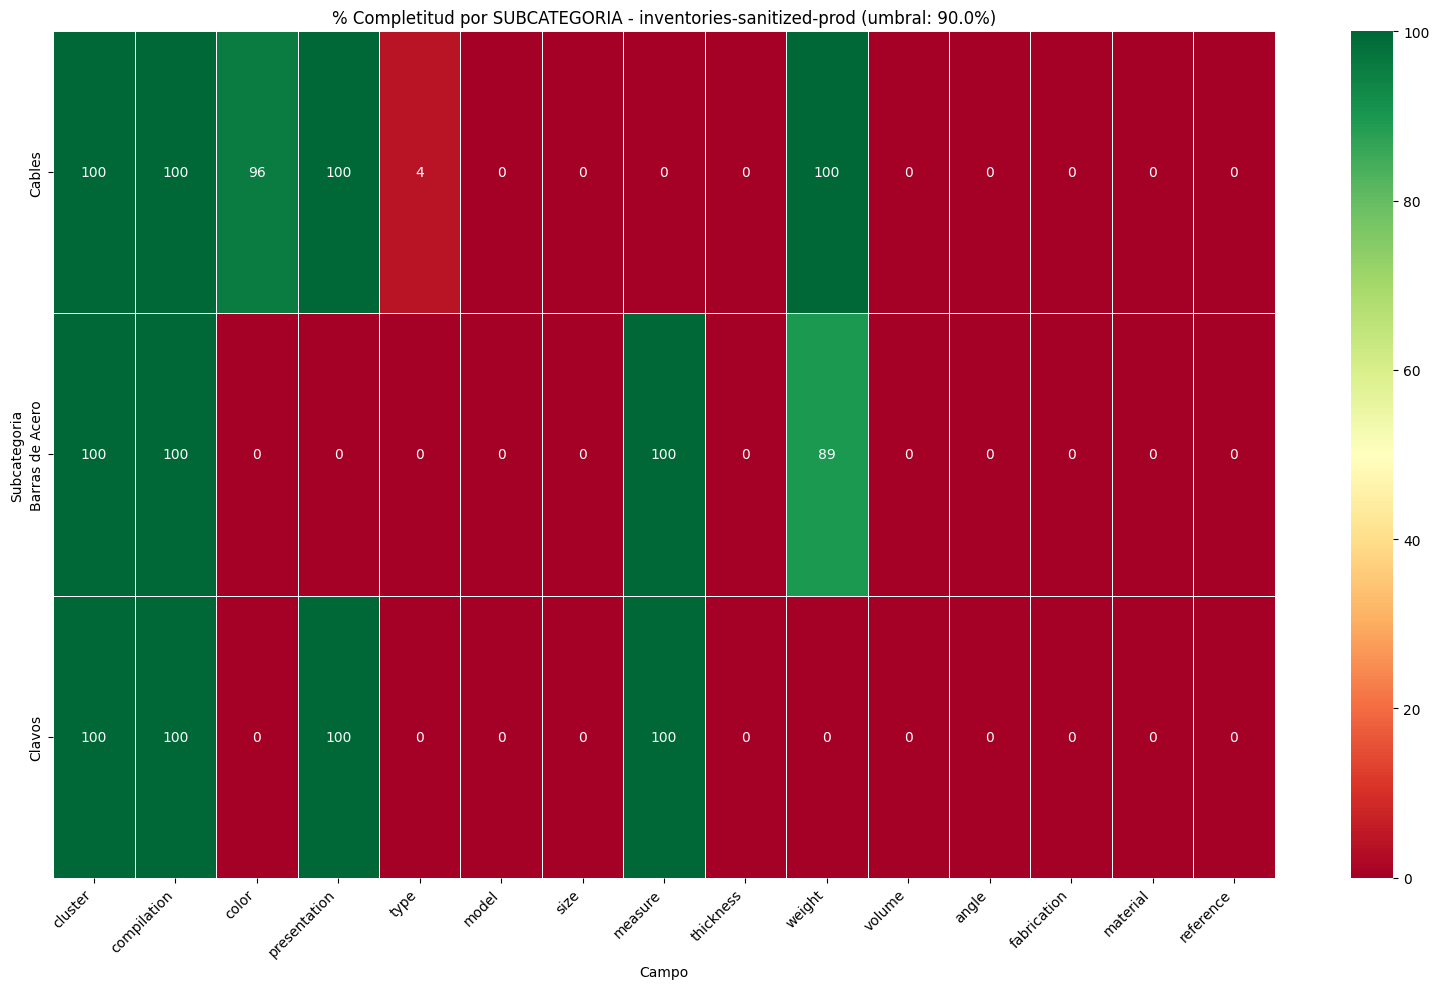

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, max(10, len(sub_completeness) * 0.4)))
sns.heatmap(
    sub_completeness, annot=True, fmt=".0f", cmap="RdYlGn",
    vmin=0, vmax=100, linewidths=0.5
)
plt.title(f"% Completitud por SUBCATEGORIA - inventories-sanitized-prod (umbral: {THRESHOLD*100}%)")
plt.xlabel("Campo")
plt.ylabel("Subcategoria")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Heatmap de Completitud por Categoría**

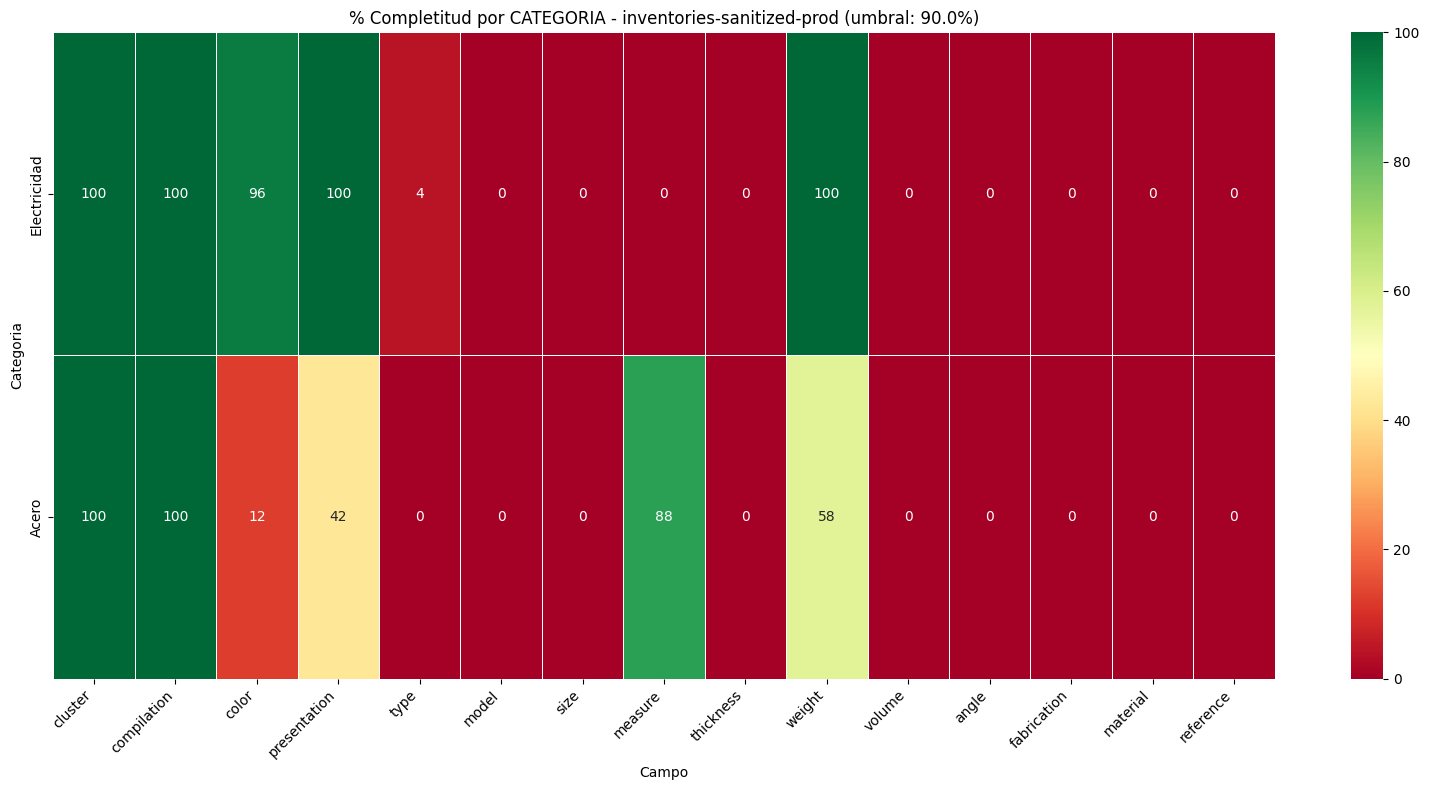

In [56]:
plt.figure(figsize=(16, max(8, len(cat_completeness) * 0.5)))
sns.heatmap(
    cat_completeness, annot=True, fmt=".0f", cmap="RdYlGn",
    vmin=0, vmax=100, linewidths=0.5
)
plt.title(f"% Completitud por CATEGORIA - inventories-sanitized-prod (umbral: {THRESHOLD*100}%)")
plt.xlabel("Campo")
plt.ylabel("Categoria")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Construir mapeo subcategory -> category**

In [57]:
subcategory_to_category = (
   df.groupby("subcategory")["category"]
   .agg(lambda x: x.value_counts().index[0])
   .to_dict()
)

**Generar schemas.json**

In [58]:
FIELD_QUESTIONS = {
    "cluster": "De que grupo?",
    "compilation": "De que conjunto?",
    "measure": "De que medida?",
    "weight": "De que peso?",
    "material": "De que material?",
    "color": "De que color?",
    "type": "De que tipo?",
    "size": "De que tamano?",
    "thickness": "De que espesor?",
    "volume": "De que volumen?",
    "presentation": "En que presentacion?",
    "model": "De que modelo?",
    "angle": "De que angulo?",
    "fabrication": "Que tipo de fabricacion?",
    "reference": "Que referencia?",
}

MAX_CHOICE_OPTIONS = 20
MIN_UNIQUE_OPTIONS = 2

def generate_schemas(df_group, group_col, completeness_df, category_map = None):
    schemas = {}
    for group_val in completeness_df.index:
        row = completeness_df.loc[group_val]
        passing_fields = row[row >= THRESHOLD * 100].index.tolist()

        required_fields = []
        field_options = {}

        for field in passing_fields:
            mask = df_group[group_col] == group_val
            values = df_group.loc[mask, field].dropna() if field in df_group.columns else pd.Series()
            clean_vals = sorted(set(
                str(v).strip() for v in values.unique()
                if v and str(v).strip()
            ))

            if len(clean_vals) < MIN_UNIQUE_OPTIONS:
                continue

            required_fields.append(field)

            if len(clean_vals) <= MAX_CHOICE_OPTIONS:
                field_options[field] = {
                    "type": "choice",
                    "question": FIELD_QUESTIONS.get(field, f"Especifica {field}:"),
                    "options": clean_vals
                }
            else:
                field_options[field] = {
                    "type": "text",
                    "question": FIELD_QUESTIONS.get(field, f"Especifica {field}:")
                }

        if required_fields:
            schema_entry = {
                "required_fields": required_fields,
                "field_options": field_options
            }
            if category_map and group_val in category_map:
                schema_entry["category"] = category_map[group_val]
            schemas[group_val] = schema_entry

    return schemas

subcategory_schemas = generate_schemas(df, "subcategory", sub_completeness, category_map=subcategory_to_category)

print(f"Subcategorias con schema: {len(subcategory_schemas)}")

for name, schema in list(subcategory_schemas.items())[:5]:
    print(f"\n{name} (category: {schema.get('category', 'N/A')}): {schema['required_fields']}")

Subcategorias con schema: 3

Cables (category: Electricidad): ['cluster', 'compilation', 'color', 'presentation', 'weight']

Barras de Acero (category: Acero): ['measure']

Clavos (category: Acero): ['measure']


**Celda 16 - Exportar resultados**

In [60]:
import json

output = {
    "metadata": {
        "source": "BigQuery",
        "table": "maia-466013.ds_business.inventories-sanitized-prod",
        "threshold": THRESHOLD,
        "min_products": MIN_PRODUCTS,
        "total_inventories": len(df),
        "subcategories_with_schema": len(subcategory_schemas),
        "analysis_date": pd.Timestamp.now().isoformat(),
    },
    "subcategory_schemas": subcategory_schemas,
}

path = "inventory_schemas_sanitized_19_mar_2026.json"

with open(path, "w", encoding="utf-8") as f:
    json.dump(output, f, ensure_ascii=False, indent=2)

print(f"Exportado a {path}")

# Exportar matrices de completitud
sub_completeness.to_csv("completitud_subcategoria_sanitized.csv")
cat_completeness.to_csv("completitud_categoria_sanitized.csv")
print("CSVs exportados")

Exportado a inventory_schemas_sanitized_19_mar_2026.json
CSVs exportados
